# Pertemuan 06 - Ensemble Methods (Random Forest & Gradient Boosting)

| | |
|---|---|
| **Nama** | Andre Firmansyah |
| **NIM** | 105841101123 |
| **Mata Kuliah** | Machine Learning |
| **Topik** | Ensemble Methods |
| **Dataset** | Breast Cancer Wisconsin |

---
##  Tujuan

Pada pertemuan ini, tujuan yang ingin dicapai adalah:
1. Memahami konsep ensemble learning yaitu menggabungkan banyak model untuk menghasilkan prediksi yang lebih stabil dan akurat.
2. Membandingkan performa **Decision Tree**, **Random Forest**, dan **Gradient Boosting** pada dataset yang sama.
3. Membaca dan memvisualisasikan **10 fitur terpenting** dari model Random Forest.
4. Memahami pengaruh parameter **n_estimators** terhadap performa model.

---
##  Langkah Kerja

Berikut adalah alur pengerjaan notebook ini:
1. Import semua library yang dibutuhkan
2. Memuat dan membagi dataset Breast Cancer
3. Melatih dan mengevaluasi model Decision Tree
4. Melatih dan mengevaluasi model Random Forest
5. Menampilkan 10 fitur terpenting dari Random Forest
6. Melatih dan mengevaluasi model Gradient Boosting
7. Melakukan eksperimen tuning n_estimators
8. Membandingkan ketiga model dalam satu tabel
9. Menarik kesimpulan

---
##  Import Library

Langkah pertama adalah mengimpor semua library yang diperlukan. Selain library standar, kali ini ditambahkan RandomForestClassifier dan GradientBoostingClassifier dari Scikit-learn sebagai model ensemble yang akan diuji dan dibandingkan dengan DecisionTreeClassifier.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

---
## 1. Memuat dan Membagi Dataset

Dataset yang digunakan masih sama yaitu Breast Cancer Wisconsin dengan 569 data, 30 fitur, dan 2 kelas target. Data dibagi menjadi data latih sebanyak 80% dan data uji sebanyak 20% dengan random_state=42 agar hasil konsisten.

In [2]:
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Jumlah data latih : {len(X_train)}')
print(f'Jumlah data uji   : {len(X_test)}')
print(f'Jumlah fitur      : {X.shape[1]}')
print(f'Kelas             : {list(cancer.target_names)}')

Jumlah data latih : 455
Jumlah data uji   : 114
Jumlah fitur      : 30
Kelas             : [np.str_('malignant'), np.str_('benign')]


---
## 2. Decision Tree

Decision Tree digunakan sebagai model baseline atau pembanding dasar sebelum menggunakan model ensemble. Model ini dilatih dengan max_depth=3 agar tidak overfitting, dan hasilnya akan dibandingkan dengan Random Forest dan Gradient Boosting untuk melihat seberapa besar peningkatan yang diberikan oleh metode ensemble.

In [3]:
model_dt = DecisionTreeClassifier(max_depth=3, random_state=42)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)

acc_dt  = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt, average='weighted')
rec_dt  = recall_score(y_test, y_pred_dt, average='weighted')
f1_dt   = f1_score(y_test, y_pred_dt, average='weighted')

print('=== Evaluasi Decision Tree ===')
print(f'Accuracy  : {acc_dt:.4f}')
print(f'Precision : {prec_dt:.4f}')
print(f'Recall    : {rec_dt:.4f}')
print(f'F1-Score  : {f1_dt:.4f}')
print()
print(classification_report(y_test, y_pred_dt, target_names=cancer.target_names))

=== Evaluasi Decision Tree ===
Accuracy  : 0.9474
Precision : 0.9475
Recall    : 0.9474
F1-Score  : 0.9471

              precision    recall  f1-score   support

   malignant       0.95      0.91      0.93        43
      benign       0.95      0.97      0.96        71

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



---
## 3. Random Forest

Random Forest adalah model ensemble berbasis bagging yang melatih banyak Decision Tree secara paralel menggunakan subset data dan fitur yang berbeda-beda, kemudian menggabungkan hasil prediksi seluruh pohon melalui voting mayoritas. Dengan cara ini, Random Forest mampu mengurangi variance dan menghasilkan prediksi yang lebih stabil dibanding satu Decision Tree saja. Parameter n_estimators=100 berarti model menggunakan 100 pohon keputusan.

In [4]:
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, average='weighted')
rec_rf  = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf   = f1_score(y_test, y_pred_rf, average='weighted')

print('=== Evaluasi Random Forest ===')
print(f'Accuracy  : {acc_rf:.4f}')
print(f'Precision : {prec_rf:.4f}')
print(f'Recall    : {rec_rf:.4f}')
print(f'F1-Score  : {f1_rf:.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=cancer.target_names))

=== Evaluasi Random Forest ===
Accuracy  : 0.9649
Precision : 0.9652
Recall    : 0.9649
F1-Score  : 0.9647

              precision    recall  f1-score   support

   malignant       0.98      0.93      0.95        43
      benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



---
## 4. Feature Importance - 10 Fitur Terpenting

Salah satu keunggulan Random Forest adalah kemampuannya untuk mengukur seberapa penting setiap fitur dalam proses pengambilan keputusan. Nilai feature importance dihitung berdasarkan seberapa banyak setiap fitur berkontribusi dalam mengurangi impurity di seluruh pohon. Pada cell ini saya menampilkan 10 fitur terpenting dalam bentuk grafik batang agar mudah dibaca dan diinterpretasikan.

C:\Users\andre\AppData\Local\Temp\ipykernel_8616\3671972629.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Fitur', data=df_importance, palette='Blues_r')


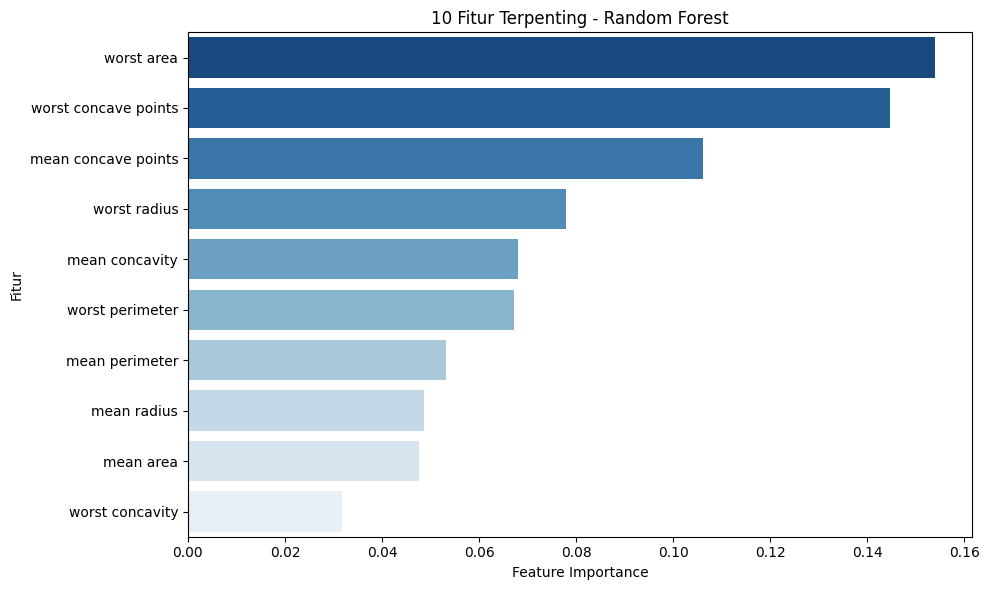

Tabel 10 Fitur Terpenting:


,Fitur,Importance
23,worst area,0.153892
27,worst concave points,0.144663
7,mean concave points,0.106210
20,worst radius,0.077987
6,mean concavity,0.068001
22,worst perimeter,0.067115
2,mean perimeter,0.053270
0,mean radius,0.048703
3,mean area,0.047555
26,worst concavity,0.031802


In [5]:
importances = model_rf.feature_importances_
feature_names = cancer.feature_names

df_importance = pd.DataFrame({
    'Fitur'      : feature_names,
    'Importance' : importances
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Fitur', data=df_importance, palette='Blues_r')
plt.title('10 Fitur Terpenting - Random Forest')
plt.xlabel('Feature Importance')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

print('Tabel 10 Fitur Terpenting:')
df_importance

---
## 5. Gradient Boosting

Gradient Boosting adalah model ensemble berbasis boosting yang melatih pohon-pohon keputusan secara berurutan, di mana setiap pohon baru difokuskan untuk memperbaiki kesalahan yang dibuat oleh pohon sebelumnya. Berbeda dengan Random Forest yang melatih pohon secara paralel dan independen, Gradient Boosting membangun model secara bertahap sehingga cenderung menghasilkan akurasi yang lebih tinggi namun membutuhkan waktu komputasi yang lebih lama.

In [6]:
model_gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
model_gb.fit(X_train, y_train)
y_pred_gb = model_gb.predict(X_test)

acc_gb  = accuracy_score(y_test, y_pred_gb)
prec_gb = precision_score(y_test, y_pred_gb, average='weighted')
rec_gb  = recall_score(y_test, y_pred_gb, average='weighted')
f1_gb   = f1_score(y_test, y_pred_gb, average='weighted')

print('=== Evaluasi Gradient Boosting ===')
print(f'Accuracy  : {acc_gb:.4f}')
print(f'Precision : {prec_gb:.4f}')
print(f'Recall    : {rec_gb:.4f}')
print(f'F1-Score  : {f1_gb:.4f}')
print()
print(classification_report(y_test, y_pred_gb, target_names=cancer.target_names))

=== Evaluasi Gradient Boosting ===
Accuracy  : 0.9561
Precision : 0.9561
Recall    : 0.9561
F1-Score  : 0.9560

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        43
      benign       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



---
## 6. Eksperimen Tuning n_estimators

Parameter n_estimators menentukan jumlah pohon keputusan yang digunakan dalam model ensemble. Semakin banyak pohon yang digunakan umumnya menghasilkan prediksi yang lebih stabil, namun juga membutuhkan waktu komputasi yang lebih lama. Pada eksperimen ini saya mencoba empat nilai n_estimators yaitu 10, 50, 100, dan 200 menggunakan Random Forest untuk melihat pengaruhnya terhadap accuracy.

In [7]:
print('=== Eksperimen Tuning n_estimators (Random Forest) ===')
hasil_n = []
for n in [10, 50, 100, 200]:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc  = accuracy_score(y_test, pred)
    hasil_n.append({'n_estimators': n, 'Accuracy': round(acc, 4)})
    print(f'n_estimators={n:<5} --> Accuracy: {acc:.4f}')

df_n = pd.DataFrame(hasil_n)
print()
print('Tabel Hasil Tuning n_estimators:')
df_n

=== Eksperimen Tuning n_estimators (Random Forest) ===
n_estimators=10    --> Accuracy: 0.9561
n_estimators=50    --> Accuracy: 0.9649
n_estimators=100   --> Accuracy: 0.9649
n_estimators=200   --> Accuracy: 0.9649

Tabel Hasil Tuning n_estimators:


,n_estimators,Accuracy
0,10,0.9561
1,50,0.9649
2,100,0.9649
3,200,0.9649


---
## 7. Perbandingan Ketiga Model

Setelah semua model dilatih dan dievaluasi, ketiga model dibandingkan dalam satu tabel untuk menentukan model mana yang paling optimal digunakan pada dataset Breast Cancer ini.

In [8]:
perbandingan = pd.DataFrame({
    'Model'     : ['Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'Accuracy'  : [round(acc_dt, 4), round(acc_rf, 4), round(acc_gb, 4)],
    'Precision' : [round(prec_dt, 4), round(prec_rf, 4), round(prec_gb, 4)],
    'Recall'    : [round(rec_dt, 4), round(rec_rf, 4), round(rec_gb, 4)],
    'F1-Score'  : [round(f1_dt, 4), round(f1_rf, 4), round(f1_gb, 4)]
})

print('Tabel Perbandingan Ketiga Model:')
perbandingan

Tabel Perbandingan Ketiga Model:


,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.9474,0.9475,0.9474,0.9471
1,Random Forest,0.9649,0.9652,0.9649,0.9647
2,Gradient Boosting,0.9561,0.9561,0.9561,0.9560


---
##  Kesimpulan

Berdasarkan hasil praktikum yang telah dilakukan, dapat disimpulkan beberapa hal:

1. Model ensemble (Random Forest dan Gradient Boosting) terbukti menghasilkan performa yang lebih baik dibanding Decision Tree tunggal, karena dengan menggabungkan banyak model sekaligus kesalahan prediksi dapat diminimalkan secara signifikan.

2. Fitur yang paling berpengaruh dalam klasifikasi tumor berdasarkan Random Forest adalah fitur-fitur yang berkaitan dengan ukuran dan bentuk sel, yang sesuai dengan pengetahuan medis bahwa ukuran sel tumor ganas cenderung lebih besar dan tidak beraturan.

3. Penambahan nilai n_estimators meningkatkan stabilitas model hingga titik tertentu, namun setelah mencapai jumlah pohon yang cukup peningkatan akurasi menjadi semakin kecil sementara waktu komputasi terus bertambah.